Name Vaishnavi Hemant Phalke

PRN 1252090032

Roll no: 47

Assignment 5.Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc. Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving uber.csv to uber.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score


In [ ]:
df = pd.read_csv('uber.csv')
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [ ]:
df.shape

(200000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [ ]:
df.drop(['Unnamed: 0', 'key'], axis=1, inplace=True)


In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

In [ ]:
df = df[(df['fare_amount'] > 0) & (df['passenger_count'] > 0)].copy()


Uber fares can vary based on time-related factors such as:

time of day

month

year

Since machine learning models cannot directly understand datetime values, we convert the datetime column into useful numerical features.

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

df.drop('pickup_datetime', axis=1, inplace=True)

Feature Engineering – Distance Calculation

The distance between the pickup and drop-off locations is calculated using the Haversine formula.

Haversine Formula:
The Haversine formula is a mathematical method used to compute the shortest distance between two points on the Earth’s surface using their latitude and longitude coordinates. This distance is known as the great-circle distance.

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

In [ ]:
df['distance_km']

,distance_km
0,1.683323
1,2.457590
2,5.036377
3,1.661683
4,4.475450
...,...
199995,0.112210
199996,1.875050
199997,12.850319
199998,3.539715


In [ ]:
df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,distance_km
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,5,2015,1.683323
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,7,2009,2.457590
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,8,2009,5.036377
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,6,2009,1.661683
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,8,2014,4.475450
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,-73.987042,40.739367,-73.986525,40.740297,1,10,28,10,2012,0.112210
199996,7.5,-73.984722,40.736837,-74.006672,40.739620,1,1,14,3,2014,1.875050
199997,30.9,-73.986017,40.756487,-73.858957,40.692588,2,0,29,6,2009,12.850319
199998,14.5,-73.997124,40.725452,-73.983215,40.695415,1,14,20,5,2015,3.539715


II. Identify outliers: Outlier detection is used to identify and handle abnormal data points that differ significantly from the rest of the dataset.

In Uber fare prediction, extreme fare values can negatively affect model performance.

IQR:Interquartile Range (IQR) help detect and remove these outliers, improving model accuracy and reliability.

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['fare_amount'] >= Q1 - 1.5*IQR) &
        (df['fare_amount'] <= Q3 + 1.5*IQR)]


A box plot is used to visualize the distribution of the fare amount and identify outliers. Values outside the whiskers indicate unusually high or low fares.

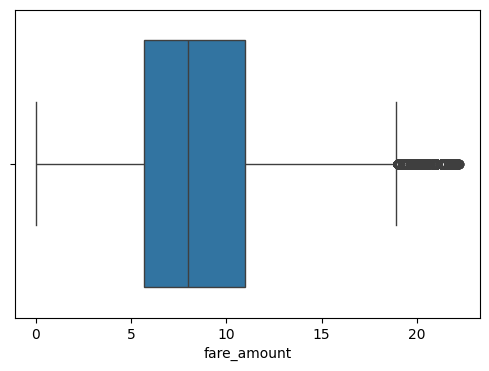

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.show()

III. Check Coorelation
Correlation is a statistical measure that shows the strength and direction of the relationship between two variables.


In our dataset, correlation shows how factors like distance and time influence Uber fares.

It assists in selecting important features and improving model performance.

In [ ]:
corr=df.corr()
corr

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,distance_km
fare_amount,1.000000,0.000125,0.002826,-0.002534,0.000715,0.011995,-0.013304,0.007128,0.026188,0.135630,0.003022
pickup_longitude,0.000125,1.000000,-0.811435,0.835878,-0.850520,-0.000582,0.003668,0.003436,-0.003842,0.009803,0.096633
pickup_latitude,0.002826,-0.811435,1.000000,-0.766797,0.683972,-0.001742,-0.004779,-0.006933,0.004069,-0.009843,-0.047525
dropoff_longitude,-0.002534,0.835878,-0.766797,1.000000,-0.913666,0.000271,0.004220,0.003941,-0.003292,0.007351,0.038328
dropoff_latitude,0.000715,-0.850520,0.683972,-0.913666,1.000000,-0.000911,-0.003373,-0.006237,0.003317,-0.009972,-0.064035
passenger_count,0.011995,-0.000582,-0.001742,0.000271,-0.000911,1.000000,0.013306,0.003378,0.009190,0.001532,-0.000153
hour,-0.013304,0.003668,-0.004779,0.004220,-0.003373,0.013306,1.000000,0.005250,-0.002835,0.003174,-0.001995
day,0.007128,0.003436,-0.006933,0.003941,-0.006237,0.003378,0.005250,1.000000,-0.016419,-0.010496,-0.003399
month,0.026188,-0.003842,0.004069,-0.003292,0.003317,0.009190,-0.002835,-0.016419,1.000000,-0.115607,-0.001312
year,0.135630,0.009803,-0.009843,0.007351,-0.009972,0.001532,0.003174,-0.010496,-0.115607,1.000000,0.026232


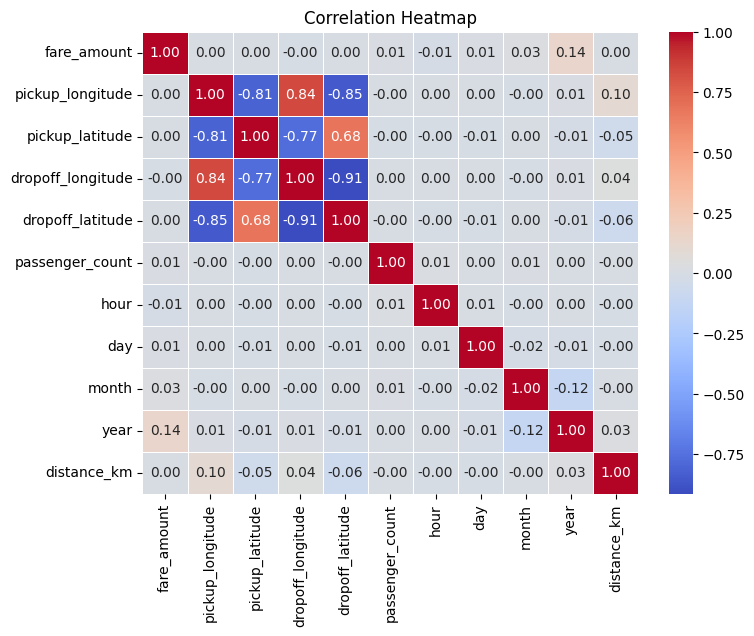

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
data={
    "Study_Hours": [2,5,3,6,4,7,1,8,2,5],
    "Attendance_Percentage": [75,90,65,95,80,98,60,85,55,88],
    "Sleep_Hours": [6,7,5,8,6,7,4,8,5,7],
    "Final_Score": [58,88,60,92,75,95,50,90,55,85]
    }

df1=pd.DataFrame(data)
df1

,Study_Hours,Attendance_Percentage,Sleep_Hours,Final_Score
0,2,75,6,58
1,5,90,7,88
2,3,65,5,60
3,6,95,8,92
4,4,80,6,75
5,7,98,7,95
6,1,60,4,50
7,8,85,8,90
8,2,55,5,55
9,5,88,7,85


In [ ]:
corr=df1.corr()
corr

,Study_Hours,Attendance_Percentage,Sleep_Hours,Final_Score
Study_Hours,1.000000,0.836283,0.901962,0.944133
Attendance_Percentage,0.836283,1.000000,0.883319,0.945322
Sleep_Hours,0.901962,0.883319,1.000000,0.920092
Final_Score,0.944133,0.945322,0.920092,1.000000


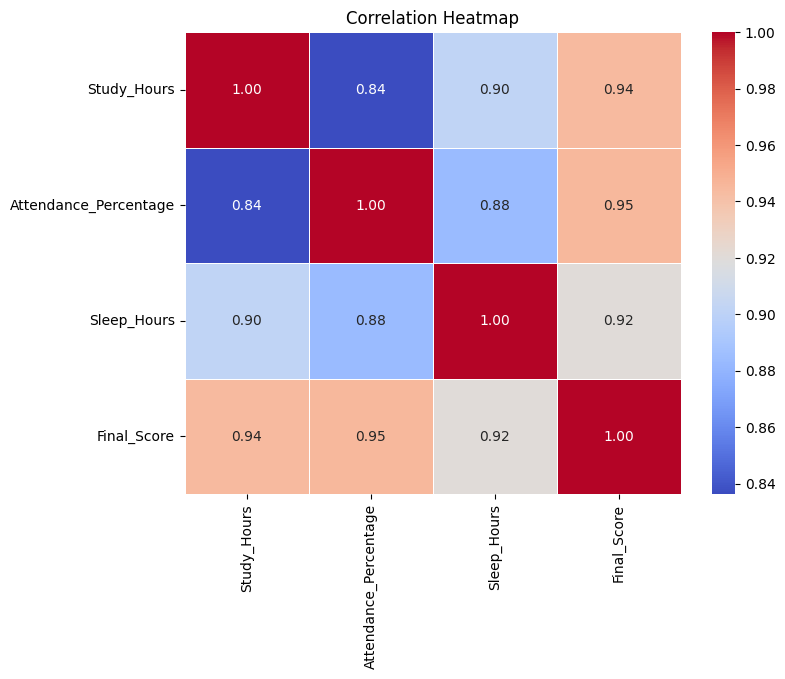

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Correlation between two specific columns such as study hours and final score

In [ ]:
corr_col=df1['Study_Hours'].corr(df1['Final_Score'])
corr_col

np.float64(0.9441329957211195)

In [ ]:
import numpy as np
x=[1,2,3,4,5,6]
y=[10,23,67,32,13,56]
corr = np.corrcoef(x,y)
print(corr)

[[1.         0.37859076]
 [0.37859076 1.        ]]


In [ ]:
corr = df1.dropna().corr()
print(corr)

                       Study_Hours  Attendance_Percentage  Sleep_Hours  \
Study_Hours               1.000000               0.836283     0.901962   
Attendance_Percentage     0.836283               1.000000     0.883319   
Sleep_Hours               0.901962               0.883319     1.000000   
Final_Score               0.944133               0.945322     0.920092   

                       Final_Score  
Study_Hours               0.944133  
Attendance_Percentage     0.945322  
Sleep_Hours               0.920092  
Final_Score               1.000000  


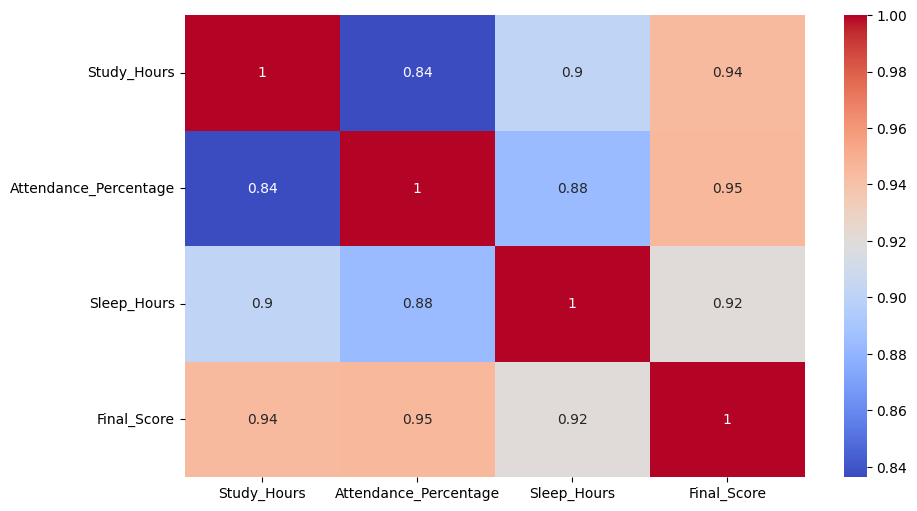

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
corr=df1.corr
corr_value=df1

Strong correlation: Pickup and drop-off latitude/longitude are strongly correlated with each other.

Moderate correlation: Fare amount and distance show a noticeable positive correlation.

Weak correlation: Fare amount with passenger count, hour, day, month, and year shows weak correlation.



IV. Implement linear regression on the Hour and marks dataset also on the Uber dataset

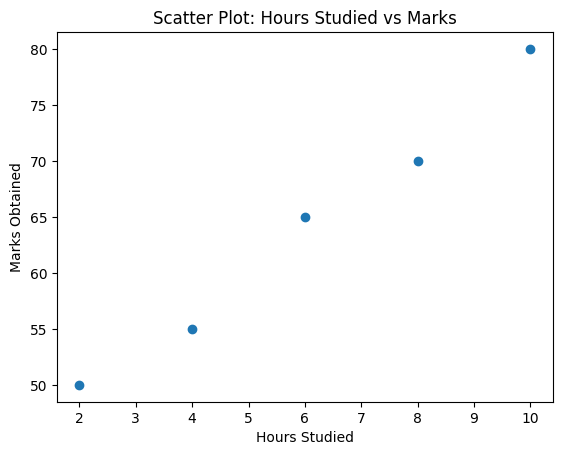

In [ ]:
import matplotlib.pyplot as plt

# Data
hours = [2, 4, 6, 8, 10]
marks = [50, 55, 65, 70, 80]

# Scatter plot
plt.scatter(hours, marks)
plt.xlabel("Hours Studied")
plt.ylabel("Marks Obtained")
plt.title("Scatter Plot: Hours Studied vs Marks")

plt.show()

In [ ]:
import pandas as pd
data={
     'Hours_Studied': [2, 4, 6, 8, 10],
     'Marks': [50, 55, 65, 75, 85]
}
df2=pd.DataFrame(data)
df2

,Hours_Studied,Marks
0,2,50
1,4,55
2,6,65
3,8,75
4,10,85


In [ ]:
from sklearn.linear_model import LinearRegression

X = df2[['Hours_Studied']]
y = df2['Marks']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 39.0
Slope: 4.5


In [ ]:
df2['predicted_values']=model.predict(X)
print(df2)

   Hours_Studied  Marks  predicted_values
0              2     50              48.0
1              4     55              57.0
2              6     65              66.0
3              8     75              75.0
4             10     85              84.0


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, df2['predicted_values'])
r2 = r2_score(y, df2['predicted_values'])

print("MSE:", mse)
print("R² Score:", r2)

MSE: 2.0
R² Score: 0.9878048780487805


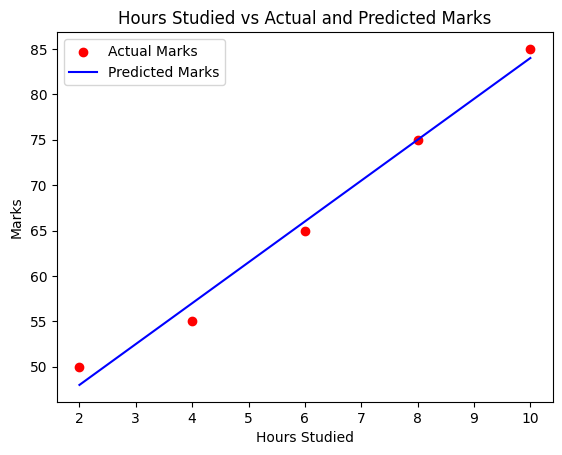

In [ ]:
plt.figure()

# Actual values (Red scatter)
plt.scatter(df2['Hours_Studied'], df2['Marks'],
            color='red', label='Actual Marks')

# Predicted values (Blue line)
plt.plot(df2['Hours_Studied'], df2['predicted_values'],
         color='blue', label='Predicted Marks')

# Labels
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Actual and Predicted Marks")

# Legend
plt.legend()

plt.show()

Linear Regression on the Uber Dataset

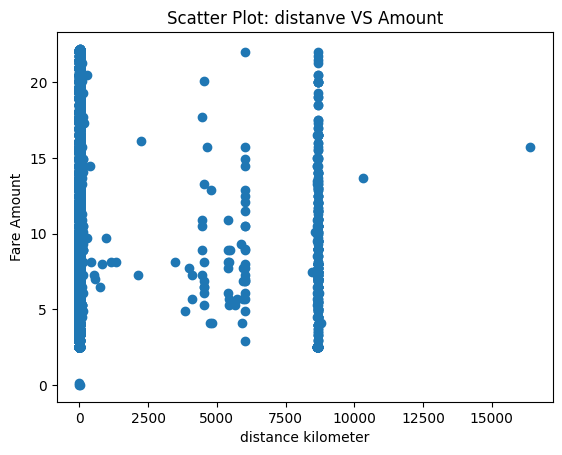

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(df['distance_km'],df['fare_amount'])
plt.xlabel("distance kilometer")
plt.ylabel("Fare Amount")
plt.title("Scatter Plot: distanve VS Amount")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['distance_km']]
y = df['fare_amount']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 8.942437479828127
Slope: 3.487982785271508e-05


In [ ]:
df['predicted_values']=model.predict(X)
print(df)

        fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
0               7.5        -73.999817        40.738354         -73.999512   
1               7.7        -73.994355        40.728225         -73.994710   
2              12.9        -74.005043        40.740770         -73.962565   
3               5.3        -73.976124        40.790844         -73.965316   
4              16.0        -73.925023        40.744085         -73.973082   
...             ...               ...              ...                ...   
199994         12.0        -73.983070        40.760770         -73.972972   
199995          3.0        -73.987042        40.739367         -73.986525   
199996          7.5        -73.984722        40.736837         -74.006672   
199998         14.5        -73.997124        40.725452         -73.983215   
199999         14.1        -73.984395        40.720077         -73.985508   

        dropoff_latitude  passenger_count  hour  day  month  year  \
0     

/tmp/ipython-input-1848995545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_values']=model.predict(X)


In [ ]:
mse = mean_squared_error(y, df['predicted_values'])
r2 = r2_score(y, df['predicted_values'])

print("MSE:", mse)
print("R² Score:", r2)

MSE: 17.158329598807125
R² Score: 9.134296455326485e-06


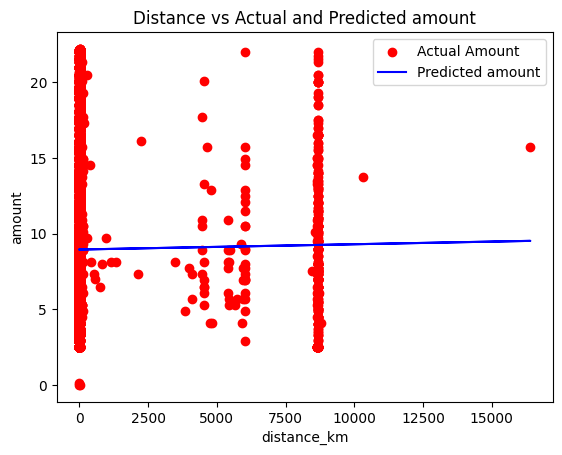

In [ ]:
plt.figure()

# Actual values (Red scatter)
plt.scatter(df['distance_km'], df['fare_amount'],
            color='red', label='Actual Amount')

# Predicted values (Blue line)
plt.plot(df['distance_km'], df['predicted_values'],
         color='blue', label='Predicted amount')

# Labels
plt.xlabel("distance_km")
plt.ylabel("amount")
plt.title("Distance vs Actual and Predicted amount")

# Legend
plt.legend()

plt.show()